In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [5]:
#LOAD DATASET

df = pd.read_csv("fruits.csv")

# Convert column names to lowercase for consistency
df.columns = df.columns.str.lower()

df.head()

,fruit_id,fruit_type,size_cm,weight_g,color_intensity,ripeness_level,firmness,sweetness,defect_count,bruise_score,spot_score,defect_score,size_to_weight_ratio,grade
0,FR00001,Peach,5.98,141.19,0.40,0.08,0.91,0.18,0,0.05,0.60,0.14,4.24,Reject
1,FR00002,Orange,7.60,154.18,0.34,0.57,0.04,0.51,1,0.10,0.44,0.17,4.93,Local
2,FR00003,Pear,9.99,207.51,0.58,0.39,0.12,0.54,2,0.42,0.45,0.32,4.82,Reject
3,FR00004,Grapes,1.86,4.54,0.34,0.48,0.94,0.76,2,0.48,0.65,0.38,40.93,Local
4,FR00005,Peach,6.13,154.68,0.78,0.63,0.13,0.35,0,0.38,0.72,0.26,3.96,Local


In [6]:
#BASIC DATA CHECK

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (10000, 14)

Columns:
 Index(['fruit_id', 'fruit_type', 'size_cm', 'weight_g', 'color_intensity',
       'ripeness_level', 'firmness', 'sweetness', 'defect_count',
       'bruise_score', 'spot_score', 'defect_score', 'size_to_weight_ratio',
       'grade'],
      dtype='object')

Missing Values:
 fruit_id                0
fruit_type              0
size_cm                 0
weight_g                0
color_intensity         0
ripeness_level          0
firmness                0
sweetness               0
defect_count            0
bruise_score            0
spot_score              0
defect_score            0
size_to_weight_ratio    0
grade                   0
dtype: int64


In [7]:
#TARGET AND FEATURES

target = "fruit_type"

X = df.drop(columns=[target])
y = df[target]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (10000, 13)
y Shape: (10000,)


In [8]:
# CREATE NEW FEATURES

# Avoid division by zero
df["sweetness_firmness_ratio"] = df["sweetness"] / (df["firmness"] + 0.0001)

# Defect density: defects relative to size
df["defect_density"] = df["defect_count"] / (df["size_cm"] + 0.0001)

# Ripeness-sweetness interaction score
df["ripeness_sweetness_score"] = df["ripeness_level"] * df["sweetness"]

print("New Features Added:")
print(["sweetness_firmness_ratio", "defect_density", "ripeness_sweetness_score"])

New Features Added:
['sweetness_firmness_ratio', 'defect_density', 'ripeness_sweetness_score']


In [10]:
# VIEW UPDTAED DATAFRAME

df.head()

,fruit_id,fruit_type,size_cm,weight_g,color_intensity,ripeness_level,firmness,sweetness,defect_count,bruise_score,spot_score,defect_score,size_to_weight_ratio,grade,sweetness_firmness_ratio,defect_density,ripeness_sweetness_score
0,FR00001,Peach,5.98,141.19,0.40,0.08,0.91,0.18,0,0.05,0.60,0.14,4.24,Reject,0.197780,0.000000,0.0144
1,FR00002,Orange,7.60,154.18,0.34,0.57,0.04,0.51,1,0.10,0.44,0.17,4.93,Local,12.718204,0.131577,0.2907
2,FR00003,Pear,9.99,207.51,0.58,0.39,0.12,0.54,2,0.42,0.45,0.32,4.82,Reject,4.496253,0.200198,0.2106
3,FR00004,Grapes,1.86,4.54,0.34,0.48,0.94,0.76,2,0.48,0.65,0.38,40.93,Local,0.808425,1.075211,0.3648
4,FR00005,Peach,6.13,154.68,0.78,0.63,0.13,0.35,0,0.38,0.72,0.26,3.96,Local,2.690238,0.000000,0.2205


In [11]:
# CHECK CORELATION OF NEW FEATURES

new_features = ["sweetness_firmness_ratio", "defect_density", "ripeness_sweetness_score"]

df[new_features].describe()

,sweetness_firmness_ratio,defect_density,ripeness_sweetness_score
count,10000.000000,10000.000000,10000.000000
mean,28.495905,0.206712,0.249992
std,405.622439,0.288495,0.220860
min,0.000000,0.000000,0.000000
25%,0.499930,0.000000,0.068400
50%,0.999661,0.118834,0.186000
75%,1.999266,0.269535,0.378325
max,10000.000000,3.389639,1.000000


In [12]:
#LABEL ENCODE TARGET

le = LabelEncoder()
df[target + "_encoded"] = le.fit_transform(df[target])

df[[target, target + "_encoded"]].head()

,fruit_type,fruit_type_encoded
0,Peach,5
1,Orange,4
2,Pear,6
3,Grapes,2
4,Peach,5


In [13]:
# PREPARE X AND y FOR FEATURE SEECTION

X = df.drop(columns=[target, target + "_encoded"])
y = df[target + "_encoded"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (10000, 16)
y Shape: (10000,)


In [14]:
#KEEP ONLY NUMERIC FEATURES

X_numeric = X.select_dtypes(include=["int64", "float64"])

print("Numeric Features Used for MI:")
print(X_numeric.columns)

Numeric Features Used for MI:
Index(['size_cm', 'weight_g', 'color_intensity', 'ripeness_level', 'firmness',
       'sweetness', 'defect_count', 'bruise_score', 'spot_score',
       'defect_score', 'size_to_weight_ratio', 'sweetness_firmness_ratio',
       'defect_density', 'ripeness_sweetness_score'],
      dtype='object')


In [15]:
#COMPUTE MUTUAL INFORMATION SCORES

mi_scores = mutual_info_classif(X_numeric, y, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X_numeric.columns,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

mi_df

,Feature,MI Score
1,weight_g,1.442113
0,size_cm,1.421990
10,size_to_weight_ratio,1.240585
12,defect_density,0.596972
13,ripeness_sweetness_score,0.006123
9,defect_score,0.005689
4,firmness,0.004996
6,defect_count,0.004156
2,color_intensity,0.000000
3,ripeness_level,0.000000


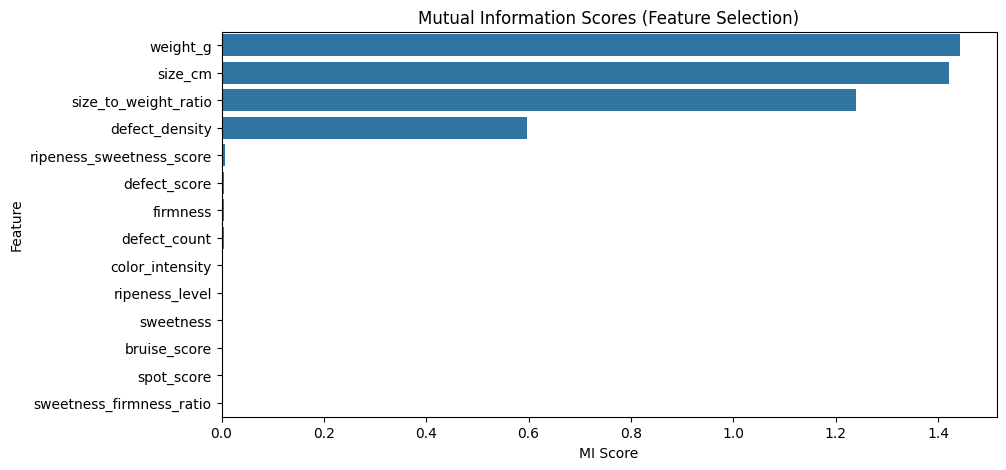

In [16]:
# VISUALIZE FEATURE IMPORTANCE (MI)

plt.figure(figsize=(10,5))
sns.barplot(x="MI Score", y="Feature", data=mi_df)
plt.title("Mutual Information Scores (Feature Selection)")
plt.show()

In [17]:
# SELECT TOP FEATURES

top_n = 8
selected_features = mi_df["Feature"].head(top_n).tolist()

print("Top Selected Features:")
selected_features

Top Selected Features:


['weight_g',
 'size_cm',
 'size_to_weight_ratio',
 'defect_density',
 'ripeness_sweetness_score',
 'defect_score',
 'firmness',
 'defect_count']

In [18]:
# SPLIT DATASET

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8000, 14)
Test: (2000, 14)


In [20]:
# BASELINE MODEL

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_base)

print("Baseline Accuracy (All Features):", baseline_acc)

Baseline Accuracy (All Features): 0.7355


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
# MODEL USING SELECTED FEATURES ONLY

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

selected_model = LogisticRegression(max_iter=1000)
selected_model.fit(X_train_selected, y_train)

y_pred_selected = selected_model.predict(X_test_selected)
selected_acc = accuracy_score(y_test, y_pred_selected)

print("Accuracy (Selected Features Only):", selected_acc)

Accuracy (Selected Features Only): 0.74


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
# STANDARDIZE DATA BEFORE PCA

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_numeric)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (10000, 14)


In [23]:
# APPLY PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original Features:", X_scaled.shape[1])
print("PCA Reduced Features:", X_pca.shape[1])

Original Features: 14
PCA Reduced Features: 10


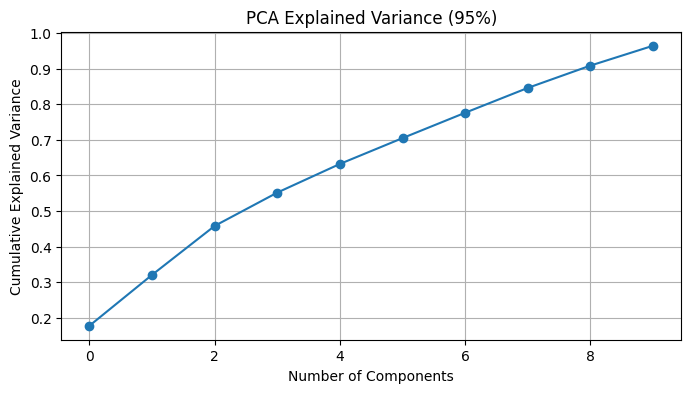

In [24]:
# VARIANCE

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance (95%)")
plt.grid(True)
plt.show()

In [25]:
#TRAIN MODEL USING PCA FEATURES

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

pca_model = LogisticRegression(max_iter=1000)
pca_model.fit(X_train_pca, y_train_pca)

y_pred_pca = pca_model.predict(X_test_pca)
pca_acc = accuracy_score(y_test_pca, y_pred_pca)

print("Accuracy after PCA:", pca_acc)

Accuracy after PCA: 0.7185


In [26]:
# PERFORMANCE COMPARISON TABLE

comparison_df = pd.DataFrame({
    "Approach": ["Baseline (All Features)", "Selected Features (MI)", "PCA (95% Variance)"],
    "Accuracy": [baseline_acc, selected_acc, pca_acc]
})

comparison_df

,Approach,Accuracy
0,Baseline (All Features),0.7355
1,Selected Features (MI),0.7400
2,PCA (95% Variance),0.7185


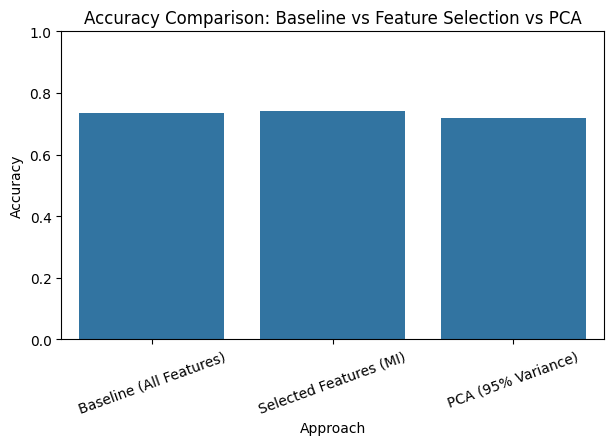

In [27]:
# PLOT COMPARISON GRAPH

plt.figure(figsize=(7,4))
sns.barplot(x="Approach", y="Accuracy", data=comparison_df)
plt.xticks(rotation=20)
plt.title("Accuracy Comparison: Baseline vs Feature Selection vs PCA")
plt.ylim(0,1)
plt.show()

In [28]:
# SAVE SELECTED FEATURES & PCA OUTPUTS

mi_df.to_csv("mutual_information_scores.csv", index=False)
comparison_df.to_csv("feature_selection_pca_comparison.csv", index=False)

print("Files saved successfully!")

Files saved successfully!
